In [20]:
from ase.io import read, write
from ase import units
import numpy as np
from imolcryff.crafter.ffxml import merge_xml
from imolcryff.trainer import DistanceTrainer
from imolcryff.calculator.distance import DistanceCalculator
from imolcryff.trainer.loss import loss_energy
from functools import partial

In [21]:
atoms_snli = read("SNLi.log")

In [22]:
merge_xml(["SN.xml", "Li.xml"], "merged.xml")

'xmlfiles/merged.xml'

In [23]:
calculator = DistanceCalculator(
    atoms_snli,
    1,
    "cn__Li",
    scan_idx=[[5,10]],
    directory="distance_scan",
    qmparams={
             "method": "wb97xd",
             "basis": "6-31g(d)",
             "opt": "modredundant",
             }
)

In [24]:
# calculator.do_qmscan()# 

In [25]:
import glob

g16logs = glob.glob("distance_scan/*.log")

In [26]:
for i, g16log in enumerate(g16logs):
    atoms = read(g16log)
    distance = atoms.get_distance(5, 10)
    energy = atoms.get_potential_energy()/(units.kJ / units.mol)
    calculator.qm_scan[0]["distance_A"].append(distance)
    calculator.qm_scan[0]["energy_kjmol"].append(energy)
    calculator.qm_scan[0]["atoms"].append(atoms)

In [27]:
# calculator.qm_scan[0]でcalculator.qm_scan[0]["distance_A"]ベースでソート
# "distance_A"の値で全リストをソート
order = np.argsort(calculator.qm_scan[0]["distance_A"])
for key in calculator.qm_scan[0]:
	calculator.qm_scan[0][key] = [calculator.qm_scan[0][key][i] for i in order]

In [28]:
calculator.do_ffscan("xmlfiles/merged.xml")

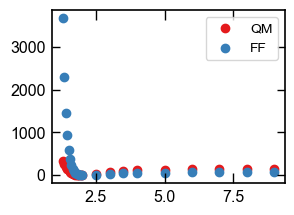

In [29]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

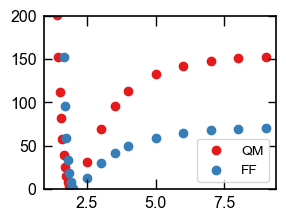

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plt.ylim(0,200)
plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

In [31]:
lossfn = partial(loss_energy, weight_scheme="uniform")

In [ ]:
dtrainer = DistanceTrainer(ffxml_list=["SN.xml", "Li.xml"], 
                           nums_ffxml=[1,1], 
                           pdbfile="hoge.pdb", 
                           calculator=calculator,
                           loss_fn=lossfn,
                        #    charge_params={"nc": 0.8, "target_lists": [[0,1,2,3,4,5,6,7,8,9]], "target_charges": [0.0]}, 
                           opt_fftypes=["NonbondedForce/charges", "NonbondedForce/sigma"],
                           # sigma_params={"target_list": [4]},
                           lr=0.0001)

In [37]:
dtrainer.ffparams

{'HarmonicBondForce': {'length': Array([0.1153, 0.1467, 0.1538, 0.1097], dtype=float64),
  'k': Array([746040.672, 247575.648, 194572.736, 314569.856], dtype=float64)},
 'HarmonicAngleForce': {'angle': Array([3.11680898, 1.94970731, 1.90956473, 1.91637152, 1.87762521],      dtype=float64),
  'k': Array([612.671488, 554.597568, 409.019472, 391.756288, 326.01728 ],      dtype=float64)},
 'PeriodicTorsionForce': {'proper_phase': Array([3.14159265, 3.14159265, 0.        , 0.        , 0.        ],      dtype=float64),
  'proper_k': Array([0.        , 0.        , 0.65084444, 0.65084444, 0.50208   ],      dtype=float64),
  'improper_phase': Array([], shape=(0,), dtype=float64),
  'improper_k': Array([], shape=(0,), dtype=float64)},
 'NonbondedForce': {'sigma': Array([0.32735182, 0.34789595, 0.33977095, 0.2600177 , 0.20259037],      dtype=float64),
  'epsilon': Array([0.4594032, 0.6677664, 0.4510352, 0.0870272, 0.0765672], dtype=float64),
  'charges': Array([-0.4450872,  0.2965618, -0.0415062,

In [38]:
from imolcryff.trainer.dmff_utils import neutralize

def grad_modify(grads):
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[10].set(0.0)
    return grads

def ffparams_modify(ffparams):
    ffparams = neutralize(ffparams, dtrainer.natoms_list, target_lists=[[0,1,2,3,4,5,6,7,8,9]], target_charges=[0.0])

    return ffparams

In [39]:
dtrainer.add_modifyfn("after_grad", grad_modify)
dtrainer.add_modifyfn("after_update", ffparams_modify)

In [40]:
dtrainer.setup()

In [42]:
dtrainer.fit(steps=2500, checkpoint_frequency=10)

Epoch 0 completed in 9.00 seconds.
Loss:  62216328.02549906
Best Loss:  62216328.02549906 at epoch  0
Epoch 1 completed in 0.08 seconds.
Loss:  62232182.317159
Best Loss:  62216328.02549906 at epoch  0
Epoch 2 completed in 0.06 seconds.
Loss:  62231807.20949157
Best Loss:  62216328.02549906 at epoch  0
Epoch 3 completed in 0.06 seconds.
Loss:  62231431.974957675
Best Loss:  62216328.02549906 at epoch  0
Epoch 4 completed in 0.07 seconds.
Loss:  62231057.618106194
Best Loss:  62216328.02549906 at epoch  0
Epoch 5 completed in 0.08 seconds.
Loss:  62230684.47101717
Best Loss:  62216328.02549906 at epoch  0
Epoch 6 completed in 0.05 seconds.
Loss:  62230312.69142373
Best Loss:  62216328.02549906 at epoch  0
Epoch 7 completed in 0.05 seconds.
Loss:  62229942.37135702
Best Loss:  62216328.02549906 at epoch  0
Epoch 8 completed in 0.05 seconds.
Loss:  62229573.57239819
Best Loss:  62216328.02549906 at epoch  0
Epoch 9 completed in 0.05 seconds.
Loss:  62229206.33978477
Best Loss:  62216328.0

KeyboardInterrupt: 

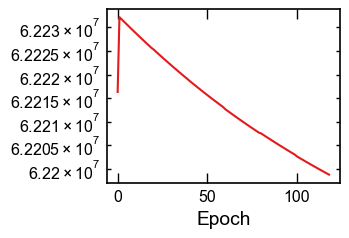

In [44]:
plt.yscale("log")
plt.xlabel("Epoch")
plt.plot(dtrainer.epochs, dtrainer.losses)